# Итоговый проект

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
orders = pd.read_csv('grocery_delivery_orders_2025_11_2026_04-ccb82362-0182-495e-b5ec-09bc3d7e541a.csv')
funnel = pd.read_csv('grocery_delivery_funnel_2025_11_2026_04-c7e6b23b-3d58-458e-a748-fa0292e891a5.csv')
communications = pd.read_csv('grocery_delivery_marketing_communications_2025_11_2026_04-66846c55-da59-4209-9b9d-d502f92e1db7.csv')


In [36]:
print('orders:', orders.shape)
print('funnel:', funnel.shape)
print('communications:', communications.shape)

orders: (21884, 21)
funnel: (144710, 23)
communications: (72193, 10)


In [37]:
orders.head()

,order_id,session_id,client_id,address_id,store_id,city,platform,order_created_at,order_date,delivery_slot_start,...,gross_merchandise_value,discount_type,discount_amount,delivery_fee,service_fee,paid_amount,payment_method,campaign_id,experiment_group,is_marketing_touched
0,O000000112,SESS000000651,C008041,A0011675,S031,Новосибирск,ios,2025-11-01 09:00:00,2025-11-01,2025-11-01 18:00:00,...,2620.76,none,0.0,0,39.31,2660.07,cash,NaN,no_campaign,0
1,O000000026,SESS000000148,C002410,A0002250,S067,Москва,ios,2025-11-01 09:18:00,2025-11-01,2025-11-01 11:00:00,...,4767.18,none,0.0,99,71.51,4937.69,card,NaN,no_campaign,0
2,O000000169,SESS000000872,C006795,A0006500,S011,Москва,ios,2025-11-01 09:19:11,2025-11-01,2025-11-01 19:00:00,...,3112.03,none,0.0,99,0.00,3211.03,card,NaN,no_campaign,0
3,O000000072,SESS000000433,C008460,A0010616,S057,Москва,web,2025-11-01 09:27:00,2025-11-01,2025-11-01 20:00:00,...,3380.14,none,0.0,99,50.70,3529.84,card,NaN,no_campaign,0
4,O000000008,SESS000000058,C008434,A0001936,S026,Екатеринбург,ios,2025-11-01 09:31:13,2025-11-01,2025-11-01 22:00:00,...,3501.61,fixed_amount,200.0,99,0.00,3400.61,card,NaN,no_campaign,0


In [38]:
funnel.head()

,session_id,client_id,address_id,session_start_at,session_date,city,platform,traffic_source,campaign_id,experiment_group,...,product_card_view,add_to_cart,cart_visit,purchase,order_id,search_at,product_card_view_at,add_to_cart_at,cart_visit_at,purchase_at
0,SESS000000514,C003975,A0000378,2025-11-01 08:04:53,2025-11-01,Москва,android,direct,NaN,no_campaign,...,1,0,0,0,NaN,2025-11-01 08:07:53,2025-11-01 08:07:53,NaN,NaN,NaN
1,SESS000000286,C000830,A0011473,2025-11-01 08:11:12,2025-11-01,Москва,android,organic,NaN,no_campaign,...,1,1,0,0,NaN,2025-11-01 08:12:12,2025-11-01 08:16:12,2025-11-01 08:23:12,NaN,NaN
2,SESS000000248,C005196,A0005849,2025-11-01 08:11:57,2025-11-01,Казань,ios,organic,NaN,no_campaign,...,1,1,1,0,NaN,2025-11-01 08:15:57,2025-11-01 08:21:57,2025-11-01 08:21:57,2025-11-01 08:31:57,NaN
3,SESS000000387,C007786,A0001717,2025-11-01 08:16:26,2025-11-01,Москва,android,direct,NaN,no_campaign,...,1,0,0,0,NaN,2025-11-01 08:18:26,2025-11-01 08:24:26,NaN,NaN,NaN
4,SESS000000197,C001541,A0001204,2025-11-01 08:21:22,2025-11-01,Санкт-Петербург,web,crm,CMP0001,test,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
communications.head()

,communication_id,campaign_id,communication_type,client_id,send_datetime,send_date,send_hour,timing_period,experiment_group,send_status
0,COM00000001,CMP0001,email,C000437,2025-11-01 18:15:00,2025-11-01,18,evening,control,holdout_control
1,COM00000002,CMP0001,email,C004047,2025-11-01 18:15:00,2025-11-01,18,evening,control,holdout_control
2,COM00000003,CMP0001,email,C003127,2025-11-01 18:15:00,2025-11-01,18,evening,test,sent
3,COM00000004,CMP0001,email,C005987,2025-11-01 18:15:00,2025-11-01,18,evening,test,sent
4,COM00000005,CMP0001,email,C002831,2025-11-01 18:15:00,2025-11-01,18,evening,test,sent


In [40]:
print(f"Пропуски в orders:{orders.isna().sum()}")
print(f"Дубликаты в orders:{orders.duplicated().sum()}")

Пропуски в orders:order_id                       0
session_id                     0
client_id                      0
address_id                     0
store_id                       0
city                           0
platform                       0
order_created_at               0
order_date                     0
delivery_slot_start            0
items_count                    0
gross_merchandise_value        0
discount_type                  0
discount_amount                0
delivery_fee                   0
service_fee                    0
paid_amount                    0
payment_method                 0
campaign_id                20838
experiment_group               0
is_marketing_touched           0
dtype: int64
Дубликаты в orders:0


In [41]:
print(f'Пропуски в funnel:{funnel.isna().sum()}')
print(f'Дубликаты в funnel: {funnel.duplicated().sum()}')

Пропуски в funnel:session_id                   0
client_id                    0
address_id                   0
session_start_at             0
session_date                 0
city                         0
platform                     0
traffic_source               0
campaign_id             138011
experiment_group             0
timing_period                0
service_visit                0
product_search               0
product_card_view            0
add_to_cart                  0
cart_visit                   0
purchase                     0
order_id                122826
search_at                40586
product_card_view_at     57949
add_to_cart_at           99732
cart_visit_at           109487
purchase_at             122826
dtype: int64
Дубликаты в funnel: 0


In [42]:
print(f'Пропуски в communications:{communications.isna().sum()}')
print(f'Дубликаты в communications:{communications.duplicated().sum()}')

Пропуски в communications:communication_id      0
campaign_id           0
communication_type    0
client_id             0
send_datetime         0
send_date             0
send_hour             0
timing_period         0
experiment_group      0
send_status           0
dtype: int64
Дубликаты в communications:0


In [43]:
orders['order_created_at'] = pd.to_datetime(orders['order_created_at'])
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['delivery_slot_start'] = pd.to_datetime(orders['delivery_slot_start'])
funnel['session_start_at'] = pd.to_datetime(funnel['session_start_at'])
funnel['session_date'] = pd.to_datetime(funnel['session_date'])
communications['send_datetime'] = pd.to_datetime(communications['send_datetime'])
communications['send_date'] = pd.to_datetime(communications['send_date'])

In [44]:
orders['order_date'].min(), orders['order_date'].max()

(Timestamp('2025-11-01 00:00:00'), Timestamp('2026-04-30 00:00:00'))

Добавим к заказам отдельный столбец с месяцем, чтобы дальше анализировать ситуацию по месяцам

In [45]:
orders['order_month'] = orders['order_date'].dt.to_period('M')

В качестве оборота в работе использую "paid_amount" (итоговую сумму оплаты клиентом)

Посчитаем по каждому месяцу оборот, количество заказов и средний чек(рассматриваем именно количество заказов со средним чеком, так как из них складывается оборот)

In [46]:
monthly_orders = pd.DataFrame()
monthly_orders['revenue'] = orders.groupby('order_month')['paid_amount'].sum()
monthly_orders['orders_count'] = orders.groupby('order_month')['order_id'].count()
monthly_orders['avg_order_value'] = orders.groupby('order_month')['paid_amount'].mean()
monthly_orders

,revenue,orders_count,avg_order_value
order_month,,,
2025-11,10693902.34,3659,2922.629773
2025-12,11573313.28,3942,2935.898853
2026-01,10874341.65,3719,2923.996141
2026-02,10250867.63,3491,2936.369989
2026-03,11573997.82,3955,2926.421699
2026-04,8797446.90,3118,2821.503175


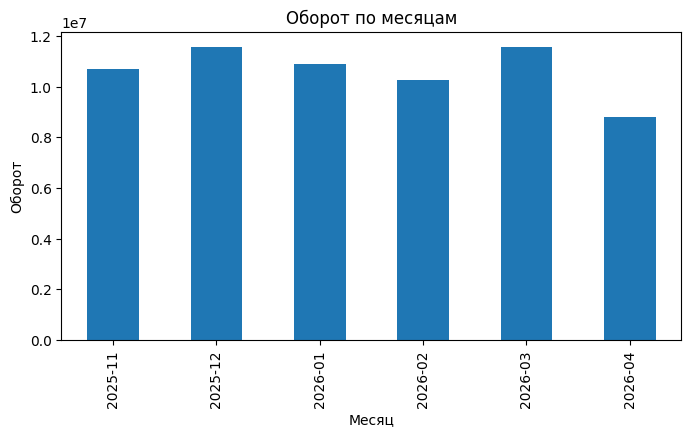

In [47]:
monthly_orders['revenue'].plot(kind='bar', figsize=(8, 4))

plt.title('Оборот по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Оборот')
plt.show()

Т.е. апрель действительно "просел"

Посчитаем изменение оборота, количества заказов и среднего чека относительно предыдущего месяца

In [48]:
monthly_orders['revenue_change'] = monthly_orders['revenue'].pct_change() * 100
monthly_orders['orders_count_change'] = monthly_orders['orders_count'].pct_change() * 100
monthly_orders['avg_order_value_change'] = monthly_orders['avg_order_value'].pct_change() * 100
monthly_orders

,revenue,orders_count,avg_order_value,revenue_change,orders_count_change,avg_order_value_change
order_month,,,,,,
2025-11,10693902.34,3659,2922.629773,NaN,NaN,NaN
2025-12,11573313.28,3942,2935.898853,8.223480,7.734354,0.454012
2026-01,10874341.65,3719,2923.996141,-6.039512,-5.657027,-0.405420
2026-02,10250867.63,3491,2936.369989,-5.733442,-6.130680,0.423183
2026-03,11573997.82,3955,2926.421699,12.907495,13.291321,-0.338796
2026-04,8797446.90,3118,2821.503175,-23.989558,-21.163085,-3.585215


В апреле оборот упал на 24% к марту, сильнее всего просело количество заказов, средний чек снизился заметно меньше, далее стоит проверить воронку: стало ли меньше сессий и на каком этапе пользователи отваливаются

Проверим динамику пользовательской воронки по месяцам

In [49]:
funnel['session_month'] = funnel['session_date'].dt.to_period('M')

In [50]:
monthly_funnel = pd.DataFrame()
monthly_funnel['sessions'] = funnel.groupby('session_month')['session_id'].count()
monthly_funnel['service_visit'] = funnel.groupby('session_month')['service_visit'].sum()
monthly_funnel['product_search'] = funnel.groupby('session_month')['product_search'].sum()
monthly_funnel['product_card_view'] = funnel.groupby('session_month')['product_card_view'].sum()
monthly_funnel['add_to_cart'] = funnel.groupby('session_month')['add_to_cart'].sum()
monthly_funnel['cart_visit'] = funnel.groupby('session_month')['cart_visit'].sum()
monthly_funnel['purchase'] = funnel.groupby('session_month')['purchase'].sum()
monthly_funnel

,sessions,service_visit,product_search,product_card_view,add_to_cart,cart_visit,purchase
session_month,,,,,,,
2025-11,23910,23910,17186,14273,7607,5942,3659
2025-12,25678,25678,18504,15466,8122,6325,3942
2026-01,24135,24135,17462,14569,7630,6012,3719
2026-02,22740,22740,16347,13666,7243,5647,3491
2026-03,25014,25014,18021,14972,7916,6249,3955
2026-04,23233,23233,16604,13815,6460,5048,3118


В апреле снизились все абсолютные показатели воронки, при этом покупки упали заметно сильнее, чем общее число сессий

In [51]:
step_conversion = pd.DataFrame()
step_conversion['search_from_visit'] = monthly_funnel['product_search'] / monthly_funnel['service_visit'] * 100
step_conversion['card_from_search'] = monthly_funnel['product_card_view'] / monthly_funnel['product_search'] * 100
step_conversion['cart_add_from_card'] = monthly_funnel['add_to_cart'] / monthly_funnel['product_card_view'] * 100
step_conversion['cart_visit_from_add'] = monthly_funnel['cart_visit'] / monthly_funnel['add_to_cart'] * 100
step_conversion['purchase_from_cart'] = monthly_funnel['purchase'] / monthly_funnel['cart_visit'] * 100
step_conversion

,search_from_visit,card_from_search,cart_add_from_card,cart_visit_from_add,purchase_from_cart
session_month,,,,,
2025-11,71.877875,83.050157,53.296434,78.112265,61.578593
2025-12,72.061687,83.581928,52.515195,77.874908,62.324111
2026-01,72.351357,83.432596,52.371474,78.794233,61.859614
2026-02,71.886544,83.599437,53.000146,77.964932,61.820436
2026-03,72.043656,83.080850,52.872028,78.941385,63.290126
2026-04,71.467309,83.202843,46.760767,78.142415,61.767036


В апреле заметно просела конверсия из просмотра карточки товара в добавление в корзину(из 53% в 47%)

Построим график конверсии из карточки товара в добавление в корзину по месяцам

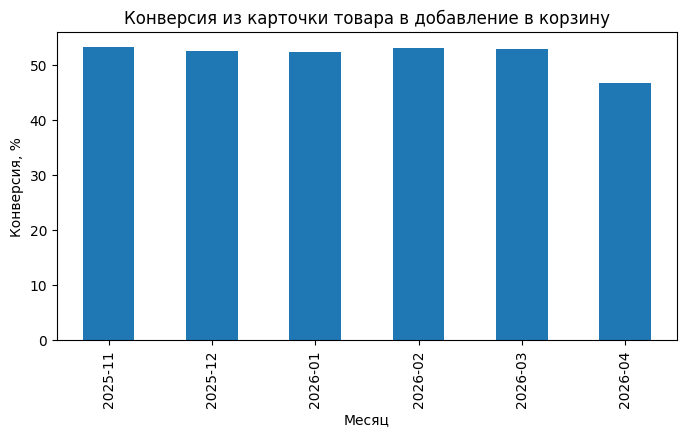

In [52]:
step_conversion['cart_add_from_card'].plot(kind='bar', figsize=(8, 4))
plt.title('Конверсия из карточки товара в добавление в корзину')
plt.xlabel('Месяц')
plt.ylabel('Конверсия, %')
plt.show()

Проверим, одинаково ли просела конверсия из карточки в корзину на разных платформах

In [53]:
platform_funnel = pd.DataFrame()
platform_funnel['card_views'] = funnel.groupby(['session_month', 'platform'])['product_card_view'].sum()
platform_funnel['add_to_cart'] = funnel.groupby(['session_month', 'platform'])['add_to_cart'].sum()
platform_funnel['cart_add_from_card'] = platform_funnel['add_to_cart'] / platform_funnel['card_views'] * 100
platform_funnel

card_views  add_to_cart  cart_add_from_card
session_month platform                                             
2025-11       android         5965         3181           53.327745
              ios             6218         3300           53.071727
              web             2090         1126           53.875598
2025-12       android         6580         3433           52.173252
              ios             6571         3446           52.442551
              web             2315         1243           53.693305
2026-01       android         6136         3261           53.145372
              ios             6249         3254           52.072332
              web             2184         1115           51.053114
2026-02       android         5939         3144           52.938205
              ios             5697         3037           53.308759
              web             2030         1062           52.315271
2026-03       android         6293         3283           52.169077
              ios             6429         3428           53.320890
              web             2250         1205           53.555556
2026-04       android         5909         2762           46.742258
              ios             5812         2738           47.109429
              web             2094          960           45.845272

Конверсия снизилась на всех платформах, значит проблема не в них

Проверим, отличается ли просадка конверсии из карточки в корзину по источникам трафика

In [54]:
traffic_funnel = pd.DataFrame()
traffic_funnel['card_views'] = funnel.groupby(['session_month', 'traffic_source'])['product_card_view'].sum()
traffic_funnel['add_to_cart'] = funnel.groupby(['session_month', 'traffic_source'])['add_to_cart'].sum()
traffic_funnel['cart_add_from_card'] = traffic_funnel['add_to_cart'] / traffic_funnel['card_views'] * 100
traffic_funnel

card_views  add_to_cart  cart_add_from_card
session_month traffic_source                                             
2025-11       crm                   2821         1485           52.640907
              direct                4871         2619           53.767194
              organic               3425         1823           53.226277
              paid                  2270         1208           53.215859
              referral               886          472           53.273138
2025-12       crm                   3098         1643           53.034216
              direct                5185         2721           52.478303
              organic               3764         1949           51.780021
              paid                  2511         1329           52.927121
              referral               908          480           52.863436
2026-01       crm                   2882         1492           51.769604
              direct                4962         2605           52.498992
              organic               3550         1901           53.549296
              paid                  2310         1189           51.471861
              referral               865          443           51.213873
2026-02       crm                   2669         1402           52.529037
              direct                4632         2453           52.957686
              organic               3270         1753           53.608563
              paid                  2207         1178           53.375623
              referral               888          457           51.463964
2026-03       crm                   2956         1584           53.585927
              direct                5138         2725           53.036201
              organic               3587         1906           53.136326
              paid                  2386         1230           51.550712
              referral               905          471           52.044199
2026-04       crm                   2784         1329           47.737069
              direct                4700         2172           46.212766
              organic               3306         1566           47.368421
              paid                  2181          976           44.750115
              referral               844          417           49.407583

Конверсия снизилась почти по всем источникам трафика, поэтому проблема не в них

Посмотрим, какие экспериментальные группы есть в данных

In [55]:
funnel['experiment_group'].value_counts()

,count
experiment_group,
no_campaign,138011
control,3364
test,3335


In [56]:
orders['experiment_group'].value_counts()

,count
experiment_group,
no_campaign,20838
test,540
control,506


Проверим проблемную конверсию из карточки в корзину по экспериментальным группам

In [57]:
group_funnel = pd.DataFrame()
group_funnel['card_views'] = funnel.groupby(['session_month', 'experiment_group'])['product_card_view'].sum()
group_funnel['add_to_cart'] = funnel.groupby(['session_month', 'experiment_group'])['add_to_cart'].sum()
group_funnel['cart_add_from_card'] = group_funnel['add_to_cart'] / group_funnel['card_views'] * 100
group_funnel

card_views  add_to_cart  cart_add_from_card
session_month experiment_group                                             
2025-11       control                  337          181           53.709199
              no_campaign            13640         7231           53.013196
              test                     296          195           65.878378
2025-12       control                  382          202           52.879581
              no_campaign            14747         7705           52.247915
              test                     337          215           63.798220
2026-01       control                  358          188           52.513966
              no_campaign            13865         7234           52.174540
              test                     346          208           60.115607
2026-02       control                  279          133           47.670251
              no_campaign            13109         6934           52.894958
              test                     278          176           63.309353
2026-03       control                  375          184           49.066667
              no_campaign            14216         7513           52.848903
              test                     381          219           57.480315
2026-04       control                  316          146           46.202532
              no_campaign            13185         6162           46.734926
              test                     314          152           48.407643

Проверим, одинаково ли просела конверсия из карточки в корзину в разных городах


In [58]:
city_funnel = pd.DataFrame()
city_funnel['card_views'] = funnel.groupby(['session_month', 'city'])['product_card_view'].sum()
city_funnel['add_to_cart'] = funnel.groupby(['session_month', 'city'])['add_to_cart'].sum()
city_funnel['cart_add_from_card'] = city_funnel['add_to_cart'] / city_funnel['card_views'] * 100
city_funnel

card_views  add_to_cart  cart_add_from_card
session_month city                                                        
2025-11       Екатеринбург           1055          541           51.279621
              Казань                 1429          751           52.554234
              Москва                 7473         3962           53.017530
              Новосибирск            1177          657           55.819881
              Санкт-Петербург        3139         1696           54.029946
2025-12       Екатеринбург           1133          590           52.074139
              Казань                 1476          775           52.506775
              Москва                 8156         4275           52.415400
              Новосибирск            1216          628           51.644737
              Санкт-Петербург        3485         1854           53.199426
2026-01       Екатеринбург           1026          515           50.194932
              Казань                 1460          775           53.082192
              Москва                 7649         3987           52.124461
              Новосибирск            1194          626           52.428811
              Санкт-Петербург        3240         1727           53.302469
2026-02       Екатеринбург           1006          560           55.666004
              Казань                 1318          699           53.034901
              Москва                 7231         3786           52.357903
              Новосибирск            1100          574           52.181818
              Санкт-Петербург        3011         1624           53.935570
2026-03       Екатеринбург           1111          589           53.015302
              Казань                 1491          773           51.844400
              Москва                 7945         4167           52.448081
              Новосибирск            1222          672           54.991817
              Санкт-Петербург        3203         1715           53.543553
2026-04       Екатеринбург           1005          495           49.253731
              Казань                 1359          608           44.738779
              Москва                 7379         3469           47.011790
              Новосибирск            1098          497           45.264117
              Санкт-Петербург        2974         1391           46.772024

Ситуация аналогична предыдущим

Проверим, как менялась конверсия из карточки в корзину по дням в марте и апреле

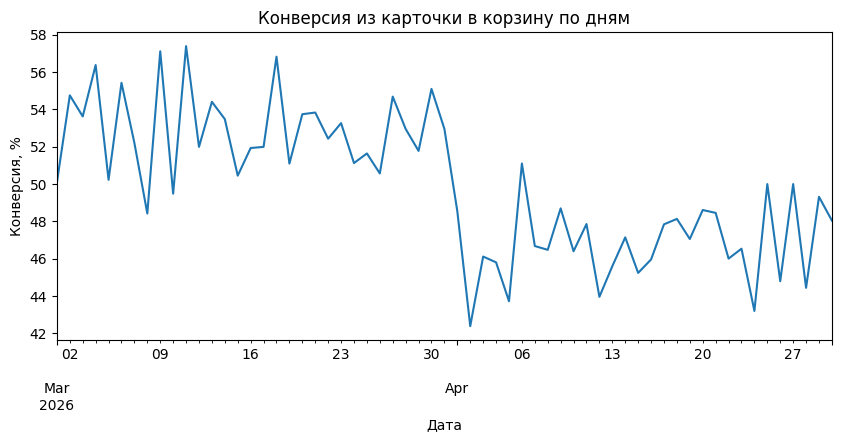

In [59]:
march_april_funnel = funnel[funnel['session_month'].astype(str).isin(['2026-03', '2026-04'])]
daily_conversion = pd.DataFrame()
daily_conversion['card_views'] = march_april_funnel.groupby('session_date')['product_card_view'].sum()
daily_conversion['add_to_cart'] = march_april_funnel.groupby('session_date')['add_to_cart'].sum()
daily_conversion['cart_add_from_card'] = daily_conversion['add_to_cart'] / daily_conversion['card_views'] * 100
daily_conversion['cart_add_from_card'].plot(figsize=(10, 4))

plt.title('Конверсия из карточки в корзину по дням')
plt.xlabel('Дата')
plt.ylabel('Конверсия, %')
plt.show()

На дневном графике видно, что конверсия из карточки в корзину упала в начале апреля и оставалась ниже мартовского уровня почти весь месяц, что свидетельствует об устойчивой проблеме

Проверим статистически, значимо ли снизилась конверсия из карточки в корзину в апреле

In [60]:
from scipy.stats import norm

march_add = monthly_funnel.loc['2026-03', 'add_to_cart']
march_views = monthly_funnel.loc['2026-03', 'product_card_view']
april_add = monthly_funnel.loc['2026-04', 'add_to_cart']
april_views = monthly_funnel.loc['2026-04', 'product_card_view']
march_rate = march_add / march_views
april_rate = april_add / april_views
p_pool = (march_add + april_add) / (march_views + april_views)

z = (april_rate - march_rate) / np.sqrt(p_pool * (1 - p_pool) * (1 / march_views + 1 / april_views))
p_value = 2 * (1 - norm.cdf(abs(z)))

pd.Series({
    'march_conversion': march_rate * 100,
    'april_conversion': april_rate * 100,
    'z_stat': z,
    'p_value': p_value
})

,0
march_conversion,52.872028
april_conversion,46.760767
z_stat,-10.360442
p_value,0.000000


p-value близок к нулю, что говорит о том, что различие статистически значимо

Проверим, за счет чего снизился средний чек

In [61]:
monthly_check = pd.DataFrame()
monthly_check['items_count'] = orders.groupby('order_month')['items_count'].mean()
monthly_check['gross_value'] = orders.groupby('order_month')['gross_merchandise_value'].mean()
monthly_check['discount'] = orders.groupby('order_month')['discount_amount'].mean()
monthly_check['delivery_fee'] = orders.groupby('order_month')['delivery_fee'].mean()
monthly_check['service_fee'] = orders.groupby('order_month')['service_fee'].mean()
monthly_check['paid_amount'] = orders.groupby('order_month')['paid_amount'].mean()
monthly_check

,items_count,gross_value,discount,delivery_fee,service_fee,paid_amount
order_month,,,,,,
2025-11,9.805138,2829.716209,48.843772,105.199235,36.558133,2922.629773
2025-12,9.754186,2844.666319,49.634340,104.748351,36.118506,2935.898853
2026-01,9.679215,2831.989392,48.186674,103.695617,36.497846,2923.996141
2026-02,9.721856,2843.469656,47.194437,104.178745,35.916033,2936.369989
2026-03,9.748420,2839.113535,54.143914,105.692035,35.760071,2926.421699
2026-04,9.827774,2728.194715,46.228178,104.954137,34.582502,2821.503175


Средний чек в апреле снизился в основном из-за падения средней стоимости товаров в заказе, количество товаров не уменьшилось, а скидки даже стали ниже, поэтому они не объясняют просадку

Проверим среднюю стоимость одного товара в заказе

In [62]:
monthly_check['value_per_item'] = monthly_check['gross_value'] / monthly_check['items_count']
monthly_check[['items_count', 'gross_value', 'value_per_item', 'paid_amount']]

,items_count,gross_value,value_per_item,paid_amount
order_month,,,,
2025-11,9.805138,2829.716209,288.595245,2922.629773
2025-12,9.754186,2844.666319,291.635448,2935.898853
2026-01,9.679215,2831.989392,292.584620,2923.996141
2026-02,9.721856,2843.469656,292.482176,2936.369989
2026-03,9.748420,2839.113535,291.238336,2926.421699
2026-04,9.827774,2728.194715,277.600467,2821.503175


Средний чек снизился из-за падения средней стоимости одного товара в заказе,  то есть это не главная причина падения оборота

Проверим, не изменилась ли в апреле активность маркетинговых коммуникаций

In [63]:
communications['send_month'] = communications['send_date'].dt.to_period('M')
communications['send_status'].value_counts()

,count
send_status,
holdout_control,36242
sent,35951


Посчитаем количество маркетинговых коммуникаций по месяцам и статусам

In [64]:
monthly_communications = pd.DataFrame()
monthly_communications['all_communications'] = communications.groupby('send_month')['communication_id'].count()
monthly_communications['sent'] = communications[communications['send_status'] == 'sent'].groupby('send_month')['communication_id'].count()
monthly_communications['holdout_control'] = communications[communications['send_status'] == 'holdout_control'].groupby('send_month')['communication_id'].count()
monthly_communications

,all_communications,sent,holdout_control
send_month,,,
2025-11,11683,5784,5899
2025-12,12955,6385,6570
2026-01,12306,6153,6153
2026-02,10324,5158,5166
2026-03,13208,6674,6534
2026-04,11717,5797,5920


Проверим, как менялось число заказов с маркетинговым касанием и без него

In [65]:
marketing_orders = pd.DataFrame()
marketing_orders['all_orders'] = orders.groupby('order_month')['order_id'].count()
marketing_orders['marketing_orders'] = orders[orders['is_marketing_touched'] == 1].groupby('order_month')['order_id'].count()
marketing_orders['not_marketing_orders'] = orders[orders['is_marketing_touched'] == 0].groupby('order_month')['order_id'].count()
marketing_orders

,all_orders,marketing_orders,not_marketing_orders
order_month,,,
2025-11,3659,162,3497
2025-12,3942,212,3730
2026-01,3719,192,3527
2026-02,3491,147,3344
2026-03,3955,190,3765
2026-04,3118,143,2975


Количество заказов снизилось и среди маркетинговых, и среди обычных заказов. Основная потеря пришлась на заказы без маркетингового касания, поэтому падение нельзя объяснить только маркетингом

Соберем ключевые показатели за март и апрель в одну таблицу

In [66]:
summary = pd.DataFrame()
summary['march'] = [
    monthly_orders.loc['2026-03', 'revenue'],
    monthly_orders.loc['2026-03', 'orders_count'],
    monthly_orders.loc['2026-03', 'avg_order_value'],
    monthly_funnel.loc['2026-03', 'sessions'],
    monthly_funnel.loc['2026-03', 'purchase'],
    step_conversion.loc['2026-03', 'cart_add_from_card']
]

summary['april'] = [
    monthly_orders.loc['2026-04', 'revenue'],
    monthly_orders.loc['2026-04', 'orders_count'],
    monthly_orders.loc['2026-04', 'avg_order_value'],
    monthly_funnel.loc['2026-04', 'sessions'],
    monthly_funnel.loc['2026-04', 'purchase'],
    step_conversion.loc['2026-04', 'cart_add_from_card']
]

summary.index = ['revenue', 'orders_count', 'avg_order_value', 'sessions', 'purchases', 'card_to_cart_conversion']
summary['change_%'] = (summary['april'] - summary['march']) / summary['march'] * 100
summary

,march,april,change_%
revenue,1.157400e+07,8.797447e+06,-23.989558
orders_count,3.955000e+03,3.118000e+03,-21.163085
avg_order_value,2.926422e+03,2.821503e+03,-3.585215
sessions,2.501400e+04,2.323300e+04,-7.120013
purchases,3.955000e+03,3.118000e+03,-21.163085
card_to_cart_conversion,5.287203e+01,4.676077e+01,-11.558589


## Итоговые выводы и рекомендации

В апреле оборот сервиса заметно снизился: с 11.57 млн до 8.80 млн, то есть почти на 24% относительно марта. Основной вклад в это падение внесло снижение количества покупок: заказов стало меньше на 21.2%. Средний чек тоже снизился, но слабее, всего на 3.6%, поэтому он скорее усилил просадку, а не был ее главной причиной.

Дальше я посмотрел пользовательскую воронку. Общее число сессий в апреле снизилось только на 7.1%, а покупок стало меньше на 21.2%. Значит, проблема не только в том, что в сервис пришло меньше пользователей. Часть пользователей стала хуже доходить до покупки.

Главное слабое место оказалось на шаге «просмотр карточки товара → добавление в корзину». В марте эта конверсия была 52.9%, а в апреле упала до 46.8%. Остальные переходы воронки изменились намного меньше. Z-тест также подтвердил, что это снижение статистически значимо: p-value близок к нулю.
Я дополнительно проверил этот переход по платформам, источникам трафика, городам и экспериментальным группам. Просадка повторяется почти везде, поэтому она не похожа на проблему одной платформы, одного города, одного канала привлечения или отдельной маркетинговой кампании. Дневной график тоже показывает, что конверсия упала в начале апреля и оставалась ниже мартовского уровня почти весь месяц. Это больше похоже на устойчивую системную проблему.

Средний чек в апреле тоже снизился. При этом среднее количество товаров в заказе не уменьшилось, а средняя стоимость одного товара стала ниже. Поэтому снижение среднего чека, скорее всего, связано не с размером корзины, а с тем, что пользователи покупали более дешевые товары.

Маркетинговые коммуникации не выглядят главной причиной падения. Количество заказов снизилось и среди заказов с маркетинговым касанием, и среди обычных заказов. Основная потеря пришлась именно на заказы без маркетингового касания.

Главный вывод: падение оборота в апреле в первую очередь связано с тем, что пользователи стали хуже добавлять товары в корзину после просмотра карточки товара. По текущим данным можно уверенно определить проблемный участок воронки, но нельзя точно доказать физическую причину.

Рекомендации:

1. Проверить, были ли в конце марта или начале апреля изменения в карточке товара: дизайн, кнопка добавления в корзину, отображение цены, скидки, наличие товара.
2. Проверить технические логи события add_to_cart: не выросли ли ошибки при добавлении товара в корзину.
3. Посмотреть данные по наличию товаров в апреле. Если популярные товары чаще были недоступны, это могло снизить переход из карточки в корзину.
4. Проверить изменение цен и ассортимента, особенно по популярным товарам и категориям.
5. После исправлений отслеживать именно конверсию «карточка товара → добавление в корзину», потому что сейчас это главный проблемный показатель.